In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data = pd.read_csv("DUDU-BLDC/Data/AnalysisData/motors.csv")

In [3]:
data.head()

,Unnamed: 0,CURRENT (A) mean,CURRENT (A) std,CURRENT (A) max,CURRENT (A) rms,CURRENT (A) peak_to_peak,CURRENT (A) skew,CURRENT (A) kurtosis,CURRENT (A) crest_factor,ROTO (RPM) mean,...,CURRENT (A) Spectrum Area,CURRENT (A) Amp @ 1x RPM,CURRENT (A) Amp @ 2x RPM,CURRENT (A) Amp @ 3x RPM,ROTO (RPM) Frequency Center,ROTO (RPM) Spectrum Area,ROTO (RPM) Amp @ 1x RPM,ROTO (RPM) Amp @ 2x RPM,ROTO (RPM) Amp @ 3x RPM,Class
0,0,4.282267,0.959033,7.273976,4.388340,5.975432,0.058508,-0.379241,1.698627,22969.800642,...,1.292779e+06,64.514344,192.412822,979.120670,9348.489312,1.890388e+09,77752.666640,166198.451004,166198.451004,Elec_Damage
1,1,4.240193,0.963069,7.298392,4.348185,6.110936,0.058439,-0.365732,1.721241,22970.527609,...,1.305889e+06,57.439401,361.476734,274.897913,9393.279908,1.894902e+09,29582.295619,177100.682568,177100.682568,Elec_Damage
2,2,4.239738,0.966752,7.439992,4.348559,6.341648,0.047411,-0.363346,1.754823,22972.986171,...,1.315128e+06,843.010592,275.595755,105.248133,9123.764068,1.849158e+09,83713.253702,23324.721909,23324.721909,Elec_Damage
3,3,4.242071,0.969813,7.300832,4.351515,6.226904,0.034595,-0.381739,1.721054,22974.758331,...,1.304290e+06,632.362919,216.780924,105.926822,9330.988497,1.882492e+09,129477.293171,89113.839562,89113.839562,Elec_Damage
4,4,4.245892,0.961609,7.288624,4.353420,6.010832,0.047197,-0.397627,1.716630,22975.544481,...,1.319682e+06,105.244076,303.625465,77.780279,9295.572445,1.878352e+09,94966.452288,14365.635080,14365.635080,Elec_Damage


In [4]:
data.duplicated().sum()

np.int64(0)

No duplications !!

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    184 non-null    int64  
 1   CURRENT (A) mean              184 non-null    float64
 2   CURRENT (A) std               184 non-null    float64
 3   CURRENT (A) max               184 non-null    float64
 4   CURRENT (A) rms               184 non-null    float64
 5   CURRENT (A) peak_to_peak      184 non-null    float64
 6   CURRENT (A) skew              184 non-null    float64
 7   CURRENT (A) kurtosis          184 non-null    float64
 8   CURRENT (A) crest_factor      184 non-null    float64
 9   ROTO (RPM) mean               184 non-null    float64
 10  ROTO (RPM) std                184 non-null    float64
 11  ROTO (RPM) max                184 non-null    float64
 12  ROTO (RPM) rms                184 non-null    float64
 13  ROTO 

So the data has no null values

In [6]:
data['Class'].value_counts()

Class
Elec_Damage         46
Healthy             46
Mech_Elec_Damage    46
Mech_Damage         46
Name: count, dtype: int64

Class is the target variable
and perfectly balanced (no bias)
And we need to do multiclass classification since there are 4 types of classes :- Elec_Damage, Healthy, Mech_Damage and Mech_Elec_Damage

In [7]:
data.isnull().sum()

Unnamed: 0                      0
CURRENT (A) mean                0
CURRENT (A) std                 0
CURRENT (A) max                 0
CURRENT (A) rms                 0
CURRENT (A) peak_to_peak        0
CURRENT (A) skew                0
CURRENT (A) kurtosis            0
CURRENT (A) crest_factor        0
ROTO (RPM) mean                 0
ROTO (RPM) std                  0
ROTO (RPM) max                  0
ROTO (RPM) rms                  0
ROTO (RPM) peak_to_peak         0
ROTO (RPM) skew                 0
ROTO (RPM) kurtosis             0
ROTO (RPM) crest_factor         0
CURRENT (A) Frequency Center    0
CURRENT (A) Spectrum Area       0
CURRENT (A) Amp @ 1x RPM        0
CURRENT (A) Amp @ 2x RPM        0
CURRENT (A) Amp @ 3x RPM        0
ROTO (RPM) Frequency Center     0
ROTO (RPM) Spectrum Area        0
ROTO (RPM) Amp @ 1x RPM         0
ROTO (RPM) Amp @ 2x RPM         0
ROTO (RPM) Amp @ 3x RPM         0
Class                           0
dtype: int64

In [8]:
data.describe()

,Unnamed: 0,CURRENT (A) mean,CURRENT (A) std,CURRENT (A) max,CURRENT (A) rms,CURRENT (A) peak_to_peak,CURRENT (A) skew,CURRENT (A) kurtosis,CURRENT (A) crest_factor,ROTO (RPM) mean,...,CURRENT (A) Frequency Center,CURRENT (A) Spectrum Area,CURRENT (A) Amp @ 1x RPM,CURRENT (A) Amp @ 2x RPM,CURRENT (A) Amp @ 3x RPM,ROTO (RPM) Frequency Center,ROTO (RPM) Spectrum Area,ROTO (RPM) Amp @ 1x RPM,ROTO (RPM) Amp @ 2x RPM,ROTO (RPM) Amp @ 3x RPM
count,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,...,184.000000,1.840000e+02,184.000000,184.000000,184.000000,184.000000,1.840000e+02,184.000000,184.000000,184.000000
mean,91.500000,3.695297,0.974948,6.862613,3.824863,6.311503,0.033544,-0.355977,1.879285,22299.477790,...,3250.875416,1.335272e+06,839.349466,738.265920,687.582084,9575.092096,1.880391e+09,128078.418309,101767.372540,101767.372540
std,53.260367,0.564023,0.028160,0.529765,0.543072,0.288150,0.028448,0.036570,0.152590,574.564806,...,450.341732,1.026172e+05,625.576209,619.812196,542.484195,168.953843,2.469224e+07,82854.351369,57486.255850,57486.255850
min,0.000000,3.042636,0.888497,6.116728,3.200628,5.708096,-0.041387,-0.420982,1.647754,21623.944117,...,2698.043127,1.012856e+06,57.439401,24.967852,17.698082,9123.764068,1.814355e+09,9137.747792,6802.709633,6802.709633
25%,45.750000,3.156146,0.960363,6.371862,3.306826,6.082244,0.012171,-0.386912,1.729991,21736.942201,...,2801.806128,1.292558e+06,428.016582,281.279153,299.505544,9457.814692,1.864742e+09,71635.835042,64477.376426,64477.376426
50%,91.500000,3.582062,0.979152,6.858320,3.713812,6.290376,0.033106,-0.360477,1.877427,22242.577133,...,3281.060834,1.350553e+06,666.659345,493.083058,522.761749,9575.758177,1.878860e+09,113363.387300,94006.569462,94006.569462
75%,137.250000,4.218445,0.995601,7.295644,4.316892,6.507672,0.051799,-0.327337,2.020353,22864.042052,...,3692.671836,1.413324e+06,1122.418141,1074.373009,934.907180,9731.833833,1.900344e+09,175914.987767,124699.805221,124699.805221
max,183.000000,4.900168,1.026084,8.162664,5.002649,7.183944,0.103741,-0.265615,2.157569,22996.800559,...,3862.771310,1.479207e+06,3837.046853,3276.884213,2757.528024,9839.695848,1.931495e+09,753453.771279,334237.763675,334237.763675


In [9]:
data = data.drop(columns=['Unnamed: 0'])

In [10]:
data.head()

,CURRENT (A) mean,CURRENT (A) std,CURRENT (A) max,CURRENT (A) rms,CURRENT (A) peak_to_peak,CURRENT (A) skew,CURRENT (A) kurtosis,CURRENT (A) crest_factor,ROTO (RPM) mean,ROTO (RPM) std,...,CURRENT (A) Spectrum Area,CURRENT (A) Amp @ 1x RPM,CURRENT (A) Amp @ 2x RPM,CURRENT (A) Amp @ 3x RPM,ROTO (RPM) Frequency Center,ROTO (RPM) Spectrum Area,ROTO (RPM) Amp @ 1x RPM,ROTO (RPM) Amp @ 2x RPM,ROTO (RPM) Amp @ 3x RPM,Class
0,4.282267,0.959033,7.273976,4.388340,5.975432,0.058508,-0.379241,1.698627,22969.800642,518.422127,...,1.292779e+06,64.514344,192.412822,979.120670,9348.489312,1.890388e+09,77752.666640,166198.451004,166198.451004,Elec_Damage
1,4.240193,0.963069,7.298392,4.348185,6.110936,0.058439,-0.365732,1.721241,22970.527609,521.269101,...,1.305889e+06,57.439401,361.476734,274.897913,9393.279908,1.894902e+09,29582.295619,177100.682568,177100.682568,Elec_Damage
2,4.239738,0.966752,7.439992,4.348559,6.341648,0.047411,-0.363346,1.754823,22972.986171,522.826496,...,1.315128e+06,843.010592,275.595755,105.248133,9123.764068,1.849158e+09,83713.253702,23324.721909,23324.721909,Elec_Damage
3,4.242071,0.969813,7.300832,4.351515,6.226904,0.034595,-0.381739,1.721054,22974.758331,525.727297,...,1.304290e+06,632.362919,216.780924,105.926822,9330.988497,1.882492e+09,129477.293171,89113.839562,89113.839562,Elec_Damage
4,4.245892,0.961609,7.288624,4.353420,6.010832,0.047197,-0.397627,1.716630,22975.544481,522.741943,...,1.319682e+06,105.244076,303.625465,77.780279,9295.572445,1.878352e+09,94966.452288,14365.635080,14365.635080,Elec_Damage


Now, our target class doesnt have numerical values, so we need to encode
And it wont affect model since it might affect regression but not classification

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Class'] = le.fit_transform(data['Class'])

In [12]:
data['Class'].value_counts()

Class
0    46
1    46
3    46
2    46
Name: count, dtype: int64

so - 0 is for Elec_Damage, 1 is for Healthy, 2 is for Mech_Elec_Damage and 3 is for Mech_Damage

In [13]:
x = data.drop('Class',axis=1)
y = data['Class']

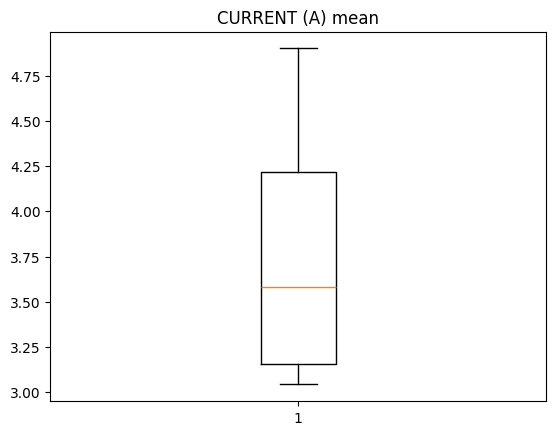

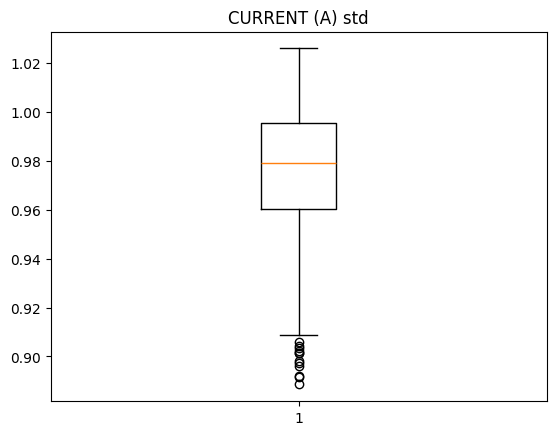

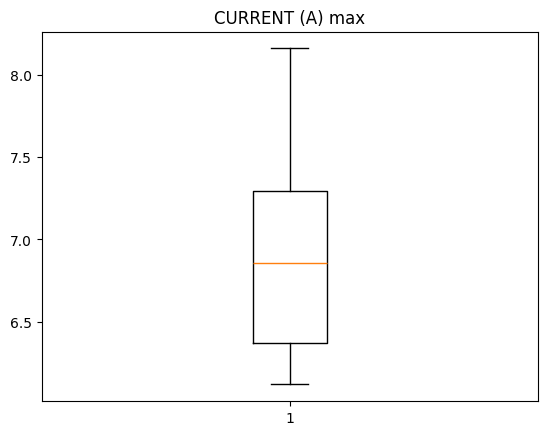

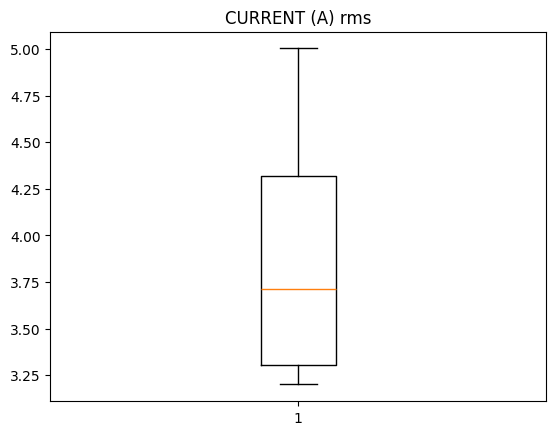

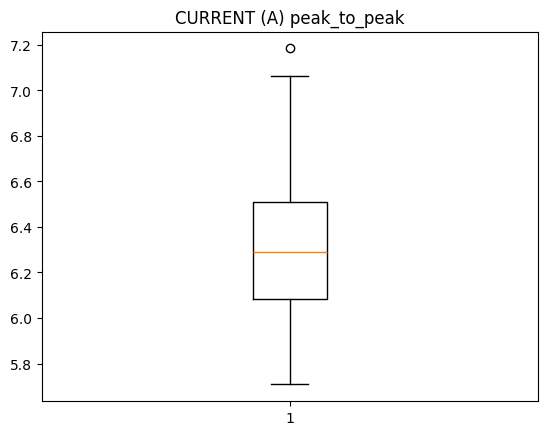

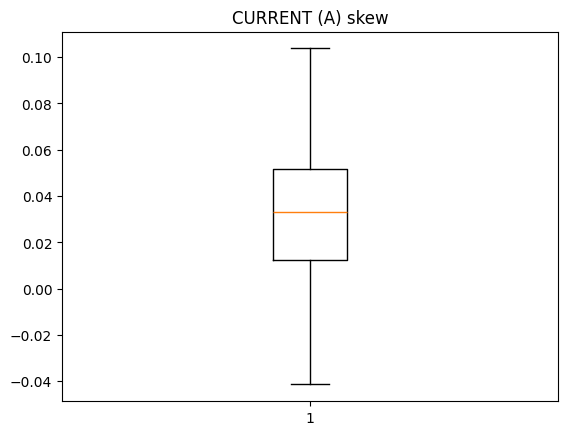

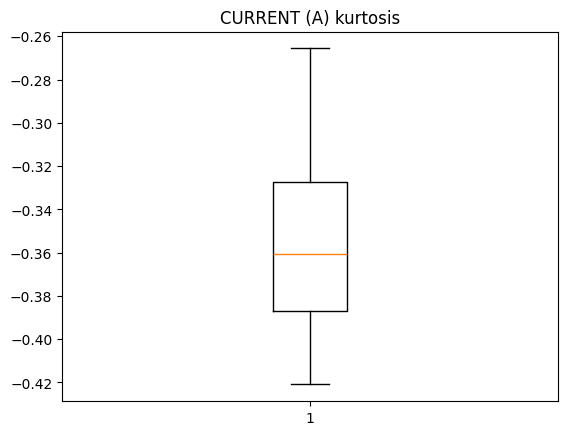

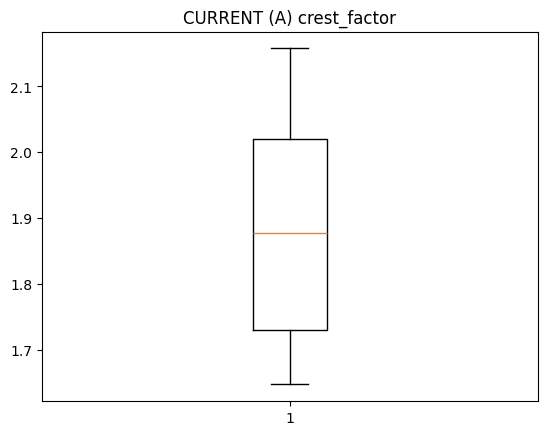

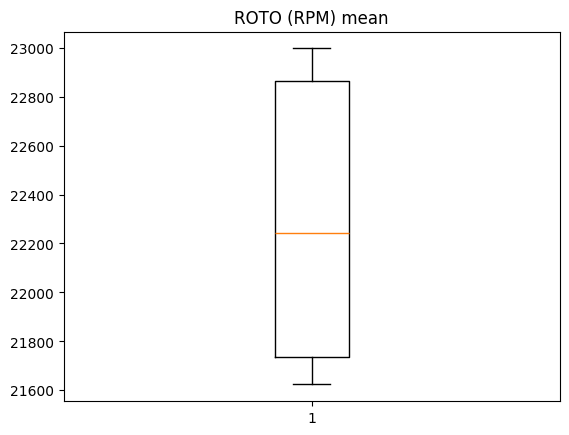

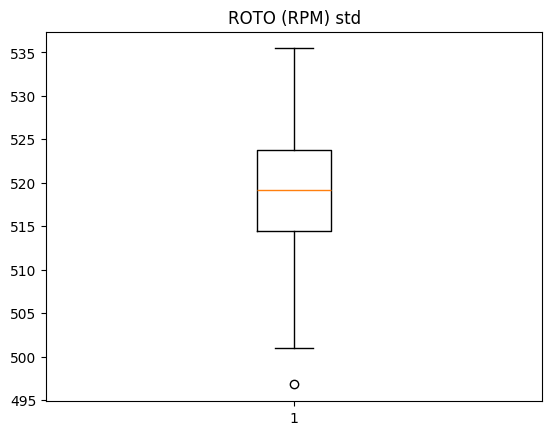

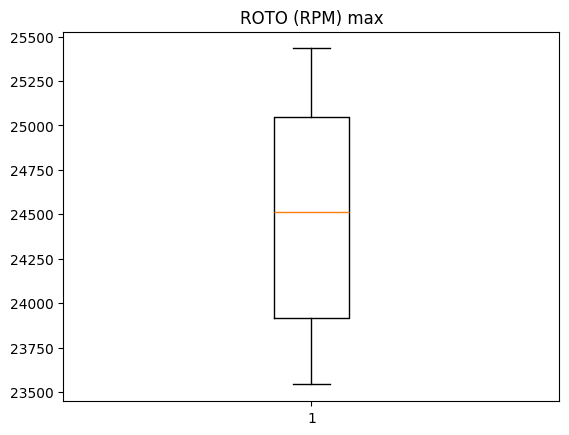

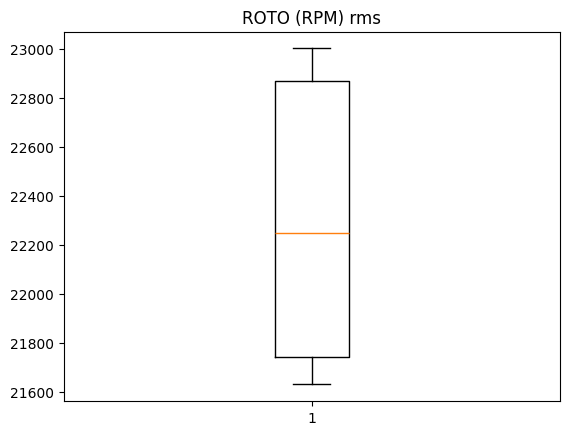

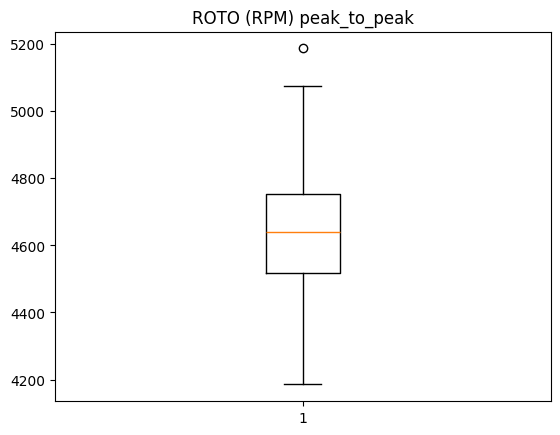

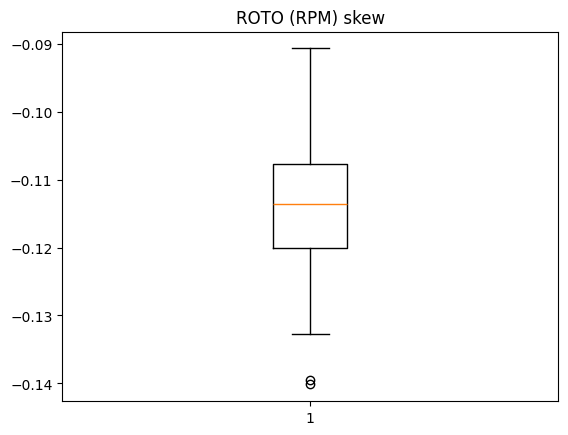

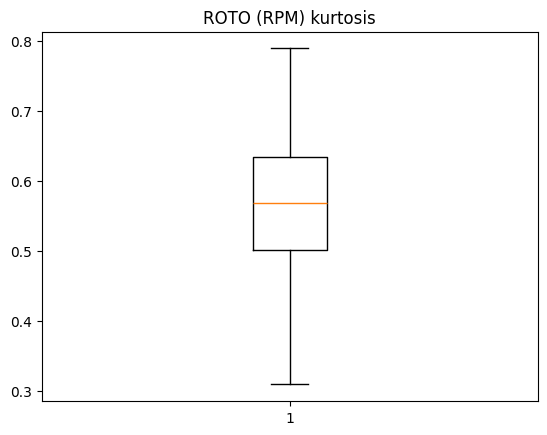

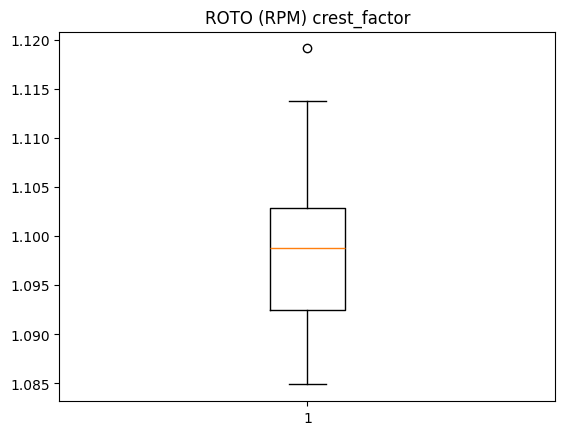

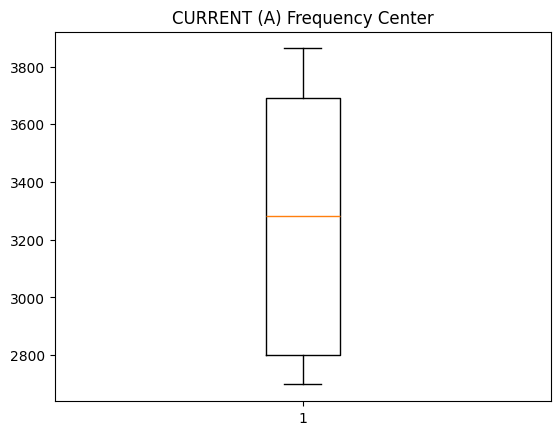

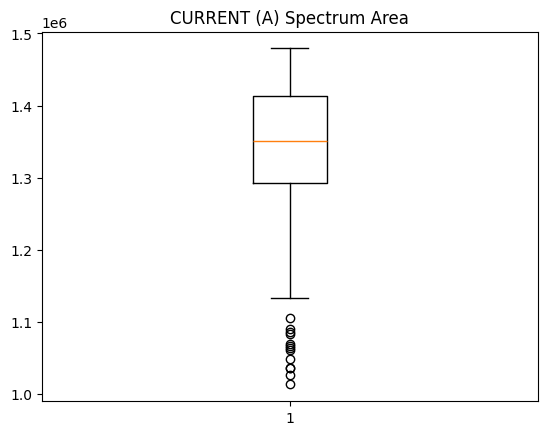

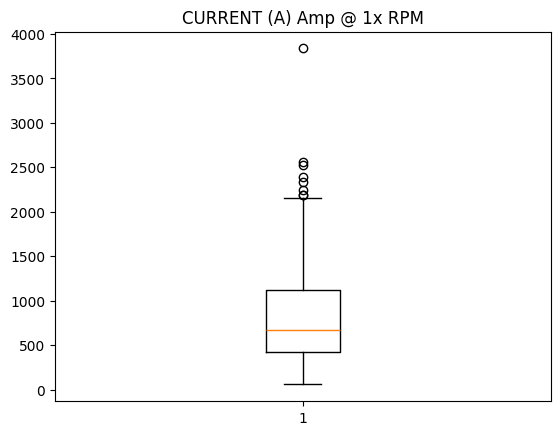

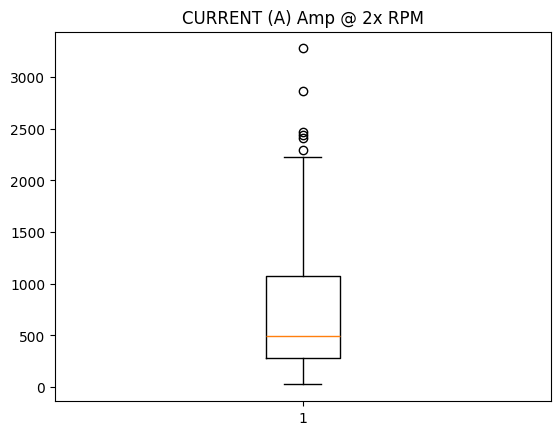

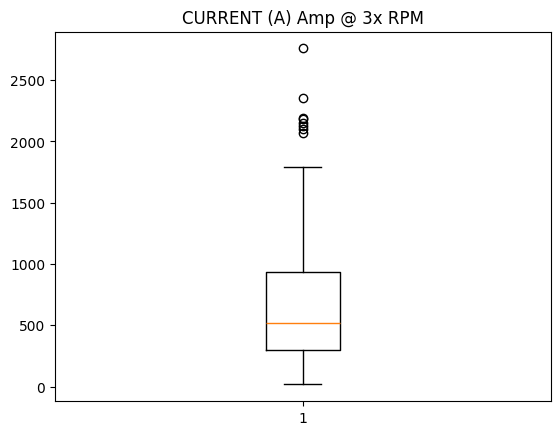

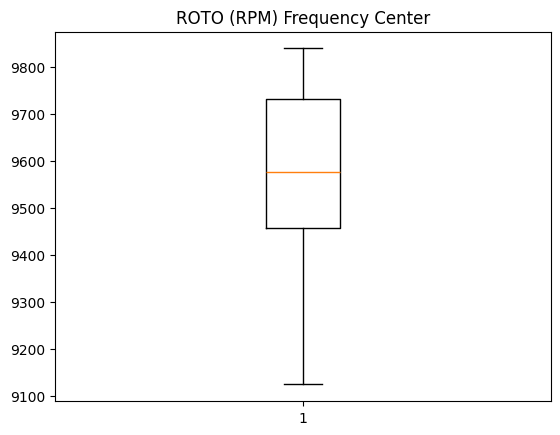

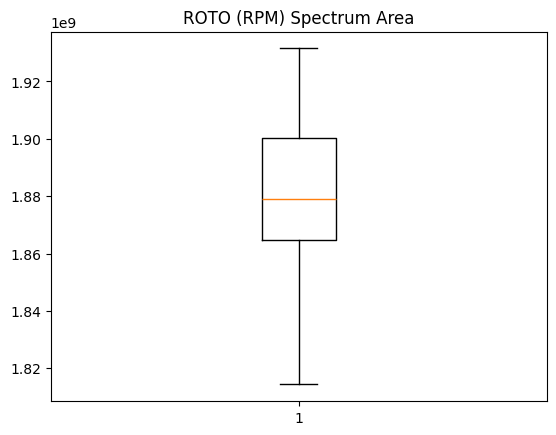

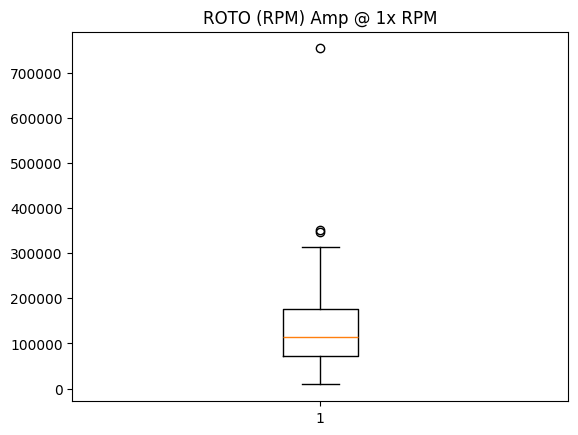

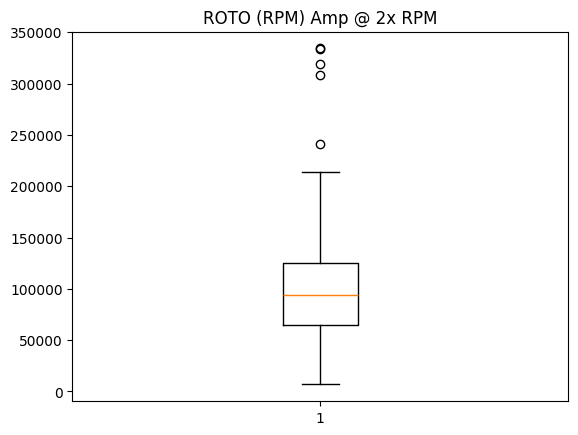

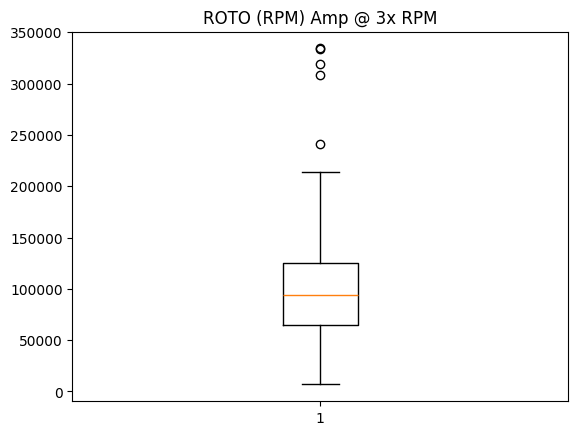

In [14]:
for col in data.columns:
    if col != 'Class':
        plt.figure()
        plt.boxplot(x[col])
        plt.title(col)
        plt.show()

We didnt remove outliers since removing them means removing faults, and we are using models like RandomForest, DecisionTrees and XGBoost that are robust to outliers and can handle them well

In [15]:
data.shape

(184, 27)

In [16]:
x.shape

(184, 26)

In [17]:
y.shape

(184,)

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
x_train.shape

(147, 26)

In [20]:
x_test.shape

(37, 26)

For models, we will be using decision tree, random forest and xgboost

<B>Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3,random_state=42)
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred_dt = dt.predict(x_test)

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [24]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test,y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         9

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



In [25]:
print("Train Accuracy:", dt.score(x_train, y_train))
print("Test Accuracy:", dt.score(x_test, y_test))

Train Accuracy: 0.9795918367346939
Test Accuracy: 1.0


This shows there is no overfitting

<B>Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_rf = rf.predict(x_test)

In [28]:
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         9

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



Data is highly separable, so now we check imp features

In [29]:
feature_imp = pd.Series(rf.feature_importances_,index=x.columns)
feature_imp = feature_imp.sort_values(ascending=False)
print(feature_imp.head(10))

ROTO (RPM) rms                  0.209542
ROTO (RPM) mean                 0.178799
CURRENT (A) mean                0.082103
CURRENT (A) max                 0.070288
CURRENT (A) rms                 0.069335
CURRENT (A) Frequency Center    0.057862
ROTO (RPM) max                  0.052119
CURRENT (A) std                 0.041406
CURRENT (A) crest_factor        0.036522
ROTO (RPM) std                  0.033612
dtype: float64


So most imp features are ROTO (RPM) rms, ROTO (RPM) mean <BR>
medium imp features are CURRENT (A) Frequency Center, CURRENT (A) max <BR>
least imp features are ROTO (RPM) max, CURRENT (A) crest_factor, ROTO (RPM) skew <br>
Means, if RPM Behaviour changes, there is a fault <br>
and these faults affect current flow patterns significantly <br>
FINAL INSIGHT :- The model identified RPM-based features as the most critical indicators, suggesting that motor speed instability is a primary signature of faults. Current-based features further help distinguish between fault types, while higher-order statistical features contribute less.

In [30]:
top_features = feature_imp.head(5).index
x_top = x[top_features]

In [31]:
x_top.head()

,ROTO (RPM) rms,ROTO (RPM) mean,CURRENT (A) mean,CURRENT (A) max,CURRENT (A) rms
0,22975.650074,22969.800642,4.282267,7.273976,4.388340
1,22976.441267,22970.527609,4.240193,7.298392,4.348185
2,22978.934577,22972.986171,4.239738,7.439992,4.348559
3,22980.772455,22974.758331,4.242071,7.300832,4.351515
4,22981.490302,22975.544481,4.245892,7.288624,4.353420


In [32]:
x_top.shape

(184, 5)

In [33]:
x.shape

(184, 26)

In [34]:
x_train_top, x_test_top, y_train, y_test = train_test_split(x_top, y, test_size=0.2, random_state=42)

In [35]:
rf_top = RandomForestClassifier(random_state=42)
rf_top.fit(x_train_top,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred_top = rf_top.predict(x_test_top)

In [37]:
print("RF Accuracy (Top Features):", accuracy_score(y_test, y_pred_top))
print(classification_report(y_test, y_pred_top))

RF Accuracy (Top Features): 0.972972972972973
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      1.00      0.95         9
           2       1.00      0.88      0.93         8
           3       1.00      1.00      1.00         9

    accuracy                           0.97        37
   macro avg       0.97      0.97      0.97        37
weighted avg       0.98      0.97      0.97        37



We only need to monitor RPM stability and current behavior to detect faults

<B>XGBoost

In [41]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb.fit(x_train_top,y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [42]:
y_pred_xgb = xgb.predict(x_test_top)

In [44]:
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB Accuracy: 0.9459459459459459
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.90      1.00      0.95         9
           2       1.00      0.88      0.93         8
           3       0.90      1.00      0.95         9

    accuracy                           0.95        37
   macro avg       0.95      0.95      0.95        37
weighted avg       0.95      0.95      0.95        37



While tree-based ensemble methods achieved perfect accuracy, XGBoost revealed slight class overlap, indicating that the dataset, though highly separable, contains borderline cases.

In [45]:
top_features

Index(['ROTO (RPM) rms', 'ROTO (RPM) mean', 'CURRENT (A) mean',
       'CURRENT (A) max', 'CURRENT (A) rms'],
      dtype='object')

In [46]:
import joblib

In [48]:
joblib.dump(dt, 'decision-tree.pkl')

['decision-tree.pkl']

In [49]:
joblib.dump(rf, 'random_forest.pkl')

['random_forest.pkl']

In [50]:
joblib.dump(xgb, 'xgboost.pkl')

['xgboost.pkl']

In [51]:
joblib.dump(top_features,'features.pkl')

['features.pkl']

In [52]:
joblib.dump(le, 'label-encoder.pkl')

['label-encoder.pkl']

In [55]:
dt = joblib.load("decision-tree.pkl")
rf = joblib.load("random_forest.pkl")
xgb = joblib.load("xgboost.pkl")
features = joblib.load("features.pkl")
le = joblib.load("label-encoder.pkl")

In [56]:
dt

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
rf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
xgb

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [59]:
features

Index(['ROTO (RPM) rms', 'ROTO (RPM) mean', 'CURRENT (A) mean',
       'CURRENT (A) max', 'CURRENT (A) rms'],
      dtype='object')

In [60]:
le

LabelEncoder()

In [61]:
top_features


Index(['ROTO (RPM) rms', 'ROTO (RPM) mean', 'CURRENT (A) mean',
       'CURRENT (A) max', 'CURRENT (A) rms'],
      dtype='object')